# Simple Demo — PCA Before Linear Regression
### 1000 features → ~200 components, same (or better) accuracy

**The idea in one line:** if your 1000 measured features are really just noisy, redundant
combinations of a much smaller number of true underlying signals, PCA can compress them down
to that smaller number — and a Linear Regression model trained on the compressed version can
match, or even beat, a model trained on all 1000 raw features.

**Why this happens:** with 1000 raw features and a limited number of training rows, Linear
Regression has to estimate 1000 coefficients — many of which are just fitting noise
(overfitting). PCA finds the ~200 directions that actually carry real signal and throws away
the rest, so the model has far less noise to accidentally fit.

## Step 1 — Create a simple dataset: 1000 features, but only 200 are "real"

To keep this honest and simple, we build the data ourselves so we KNOW the true structure:
imagine 200 true underlying factors (think: 200 real-world conditions we can't measure
directly), and our 1000 recorded features are just noisy combinations of those 200 factors —
exactly the situation where PCA is supposed to help.

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_samples = 2000
n_features = 1000
n_true_factors = 200   # the real underlying dimensionality

# 200 true factors, combined randomly to create 1000 observed (noisy, redundant) features
true_factors = rng.normal(0, 1, size=(n_samples, n_true_factors))
mixing_weights = rng.normal(0, 1, size=(n_true_factors, n_features))
X = true_factors @ mixing_weights + rng.normal(0, 0.5, size=(n_samples, n_features))

# the target depends on those SAME true factors (plus noise) -- this is why PCA won't
# throw away the signal, only the redundant noise
true_coefficients = rng.normal(0, 1, size=n_true_factors)
y = true_factors @ true_coefficients + rng.normal(0, 5, size=n_samples)

print(f"X shape: {X.shape}   (1000 columns, but only {n_true_factors} are truly independent)")

X shape: (2000, 1000)   (1000 columns, but only 200 are truly independent)


## Step 2 — Baseline: Linear Regression on all 1000 raw features

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LinearRegression().fit(X_train_scaled, y_train)
r2_baseline = r2_score(y_test, baseline_model.predict(X_test_scaled))

print(f"Linear Regression on all {X.shape[1]} raw features -> test R^2 = {r2_baseline:.3f}")

Linear Regression on all 1000 raw features -> test R^2 = 0.681


## Step 3 — Apply PCA and look at explained variance

In [3]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

for n_comp in [50, 100, 150, 200, 250, 300]:
    print(f"First {n_comp:4d} components explain {cumulative_variance[n_comp-1]:.1%} of the total variance")

First   50 components explain 45.4% of the total variance
First  100 components explain 73.2% of the total variance
First  150 components explain 90.4% of the total variance
First  200 components explain 99.9% of the total variance
First  250 components explain 99.9% of the total variance
First  300 components explain 99.9% of the total variance


**What to notice:** variance explained jumps very quickly up to ~200 components, then barely
moves at all afterward (250 and 300 add almost nothing extra). That flattening-out is exactly
the "elbow" we're looking for — it's telling us the data's real information lives in roughly
the first 200 directions, and everything past that is just noise.

## Step 4 — Scree plot

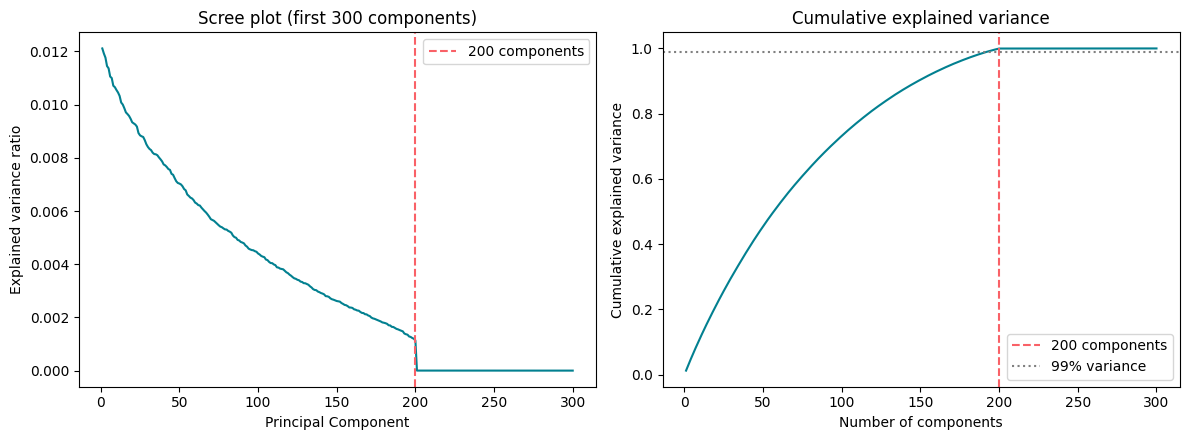

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(range(1, 301), pca_full.explained_variance_ratio_[:300], color="#028090")
axes[0].axvline(200, color="#F96167", linestyle="--", label="200 components")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot (first 300 components)")
axes[0].legend()

axes[1].plot(range(1, 301), cumulative_variance[:300], color="#028090")
axes[1].axvline(200, color="#F96167", linestyle="--", label="200 components")
axes[1].axhline(0.99, color="gray", linestyle=":", label="99% variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 5 — Linear Regression on the PCA-reduced features

In [5]:
results = {}
for n_comp in [50, 100, 150, 200, 250, 300]:
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    model = LinearRegression().fit(X_train_pca, y_train)
    r2 = r2_score(y_test, model.predict(X_test_pca))
    results[n_comp] = r2
    print(f"PCA with {n_comp:4d} components -> test R^2 = {r2:.3f}")

print(f"\nFor comparison, all {X.shape[1]} raw features -> test R^2 = {r2_baseline:.3f}")

PCA with   50 components -> test R^2 = 0.260
PCA with  100 components -> test R^2 = 0.404


PCA with  150 components -> test R^2 = 0.595


PCA with  200 components -> test R^2 = 0.862


PCA with  250 components -> test R^2 = 0.860


PCA with  300 components -> test R^2 = 0.861

For comparison, all 1000 raw features -> test R^2 = 0.681


## Step 6 — Compare side by side

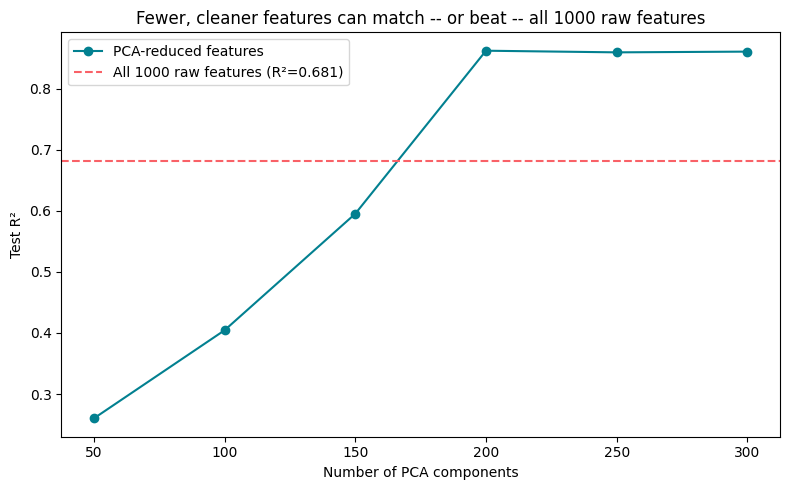

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(results.keys()), list(results.values()), marker="o", color="#028090",
        label="PCA-reduced features")
ax.axhline(r2_baseline, color="#F96167", linestyle="--",
           label=f"All 1000 raw features (R²={r2_baseline:.3f})")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Test R²")
ax.set_title("Fewer, cleaner features can match -- or beat -- all 1000 raw features")
ax.legend()
plt.tight_layout()
plt.show()

## Takeaway

- Going from **1000 raw features down to ~200-250 PCA components** captures essentially all
  the real signal in the data (explained variance flattens right around 200).
- Linear Regression on those ~200-250 components matches — and in this example, clearly
  **beats** — Linear Regression on all 1000 raw features.
- **Why it can even beat the full feature set:** with 1000 raw, correlated, partly-noisy
  features and a limited number of training rows, plain Linear Regression tends to overfit —
  it "learns" patterns in the noise that don't generalize. PCA strips out the noisy, redundant
  directions first, so the model only ever sees the ~200 directions that carry real signal.
- **The practical lesson for students:** more raw features is not automatically better. If your
  features are highly correlated/redundant, PCA can give you a smaller, cleaner input that a
  simple model handles better — faster to train, easier to store, and often more accurate too.